<h4 align="center"><i>In the name of Allah, the Most Gracious, the Most Merciful</i></h4>

# 🎓 Project Title: **Gas_Price_Analysis — Improved R² Version**


| Technique | Source | What it fixes |
|-----------|--------|----------------|
| **IQR Outlier Removal** |   3 | Reduces noise that hurts tree models |
| **Advanced Feature Engineering** |   3 | Adds domain-driven features |
| **TargetEncoder** |   2 | Better categorical encoding than OHE |
| **RobustScaler** |   3 | Resistant to remaining outliers |
| **RandomizedSearchCV** |   3 | Finds the best hyperparameters |
| **Cross-Validation** |   3 | Ensures generalization, not overfitting |
| **MLflow Tracking** |   3 | Full experiment reproducibility |

In [3]:
# --- 1. SETTING THE STAGE ---
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib

from scipy import stats

from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler, TargetEncoder
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.base import BaseEstimator, TransformerMixin

import mlflow
import mlflow.sklearn

# MLflow setup
mlflow.set_tracking_uri("sqlite:///mlflow.db")
print("✅ Libraries loaded successfully!")


✅ Libraries loaded successfully!


# 📥 Step 2: Data Loading & Basic Cleaning

In [4]:
# os.chdir(r"D:\projects\py\mohammed.AI\SAIR_ALL\SAIR_Jr\1_Regression\Regression Capstone Projects\Mohammed_Kamal")

# --- 2. DATA INGESTION ---
stations = pd.read_csv("data/gasolineras_ab.csv")
prices   = pd.read_csv('data/precios_gasolineras.csv')
df = pd.merge(prices, stations, on='id_estacion')

# Drop rows with missing target
df = df.dropna(subset=['precio_gasolina_95'])

# Remove physically impossible prices
df = df[df['precio_gasolina_95'] > 0.5]

print(f"📊 Dataset shape after basic cleaning: {df.shape}")
print(df['precio_gasolina_95'].describe())

📊 Dataset shape after basic cleaning: (40912, 13)
count    40912.000000
mean         1.669550
std          0.170286
min          1.259000
25%          1.561000
50%          1.639000
75%          1.739000
max          2.299000
Name: precio_gasolina_95, dtype: float64


# 🧹 Step 3: IQR Outlier Removal 

Standard Z-score removes only extreme values. **IQR is more robust** and was used in   3 for the California Housing dataset.

✅ IQR Outlier Removal: 40912 → 39333 rows (removed 1579)


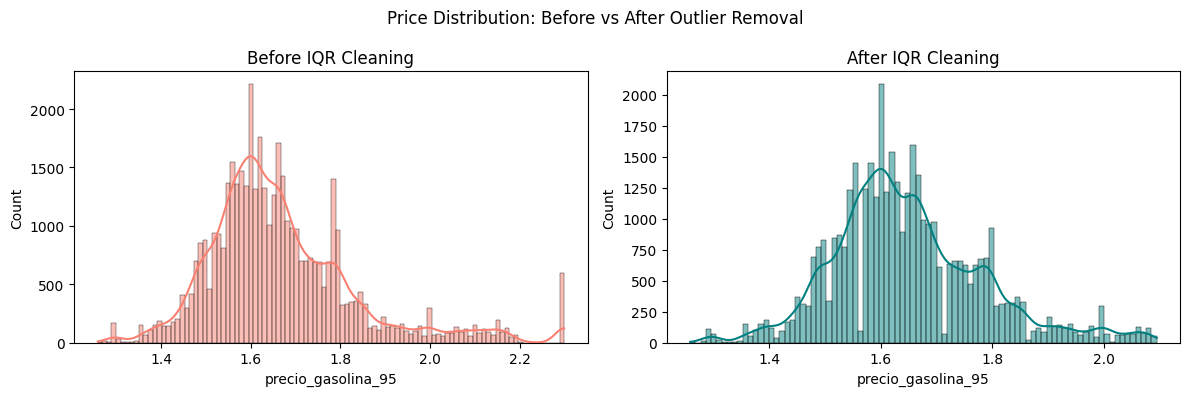

In [ ]:
# --- 3. IQR OUTLIER REMOVAL (from   3) ---
def remove_outliers_iqr(dataframe, column, multiplier=1.5):
    """Remove outliers using IQR method (  3 technique)"""
    Q1 = dataframe[column].quantile(0.25)
    Q3 = dataframe[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - multiplier * IQR
    upper = Q3 + multiplier * IQR
    mask = (dataframe[column] >= lower) & (dataframe[column] <= upper)
    return dataframe[mask]

before = len(df)
df = remove_outliers_iqr(df, 'precio_gasolina_95', multiplier=2.0)
after = len(df)

print(f"✅ IQR Outlier Removal: {before} → {after} rows (removed {before - after})")

# Visualize before/after distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(prices['precio_gasolina_95'].dropna(), kde=True, ax=axes[0], color='salmon')
axes[0].set_title('Before IQR Cleaning')
sns.histplot(df['precio_gasolina_95'], kde=True, ax=axes[1], color='teal')
axes[1].set_title('After IQR Cleaning')
plt.suptitle('Price Distribution: Before vs After Outlier Removal')
plt.tight_layout()
plt.show()

# 🛠️ Step 4: Advanced Feature Engineering 

Inspired by `AdvancedFeatureEngineer` from   3, we build a **sklearn-compatible custom transformer** for gas price domain features.

In [ ]:
# --- 4. FEATURE ENGINEERING (  3 Pattern) ---

# Parse dates and extract rich time features
df['fecha'] = pd.to_datetime(df['fecha'], format='%d/%m/%Y')
df['day_of_year'] = df['fecha'].dt.dayofyear
df['day_of_week'] = df['fecha'].dt.dayofweek
df['month']       = df['fecha'].dt.month
df['week']        = df['fecha'].dt.isocalendar().week.astype(int)

# Compute city center of Albacete (approximate centroid)
center_lat = df['latitud'].mean()
center_lon = df['longitud'].mean()

# Geographical distance from city center (inspired by   3's DistFromCenter)
df['dist_from_center'] = np.sqrt(
    (df['latitud']  - center_lat) ** 2 +
    (df['longitud'] - center_lon) ** 2
)

# Geographic quadrant (NE / NW / SE / SW)
df['geo_quadrant'] = (
    (df['latitud']  > center_lat).astype(int) * 2 +
    (df['longitud'] > center_lon).astype(int)
)

# Is it a weekend?
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)

# Cyclical encoding of time (  1 concept: function approximation)
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
df['dow_sin']   = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['dow_cos']   = np.cos(2 * np.pi * df['day_of_week'] / 7)

print(f"✅ Feature Engineering Complete!")
print(f"   New features: dist_from_center, geo_quadrant, is_weekend,")
print(f"                 month_sin/cos, dow_sin/cos, day_of_year, week")

✅ Feature Engineering Complete!
   New features: dist_from_center, geo_quadrant, is_weekend,
                 month_sin/cos, dow_sin/cos, day_of_year, week


# ⚙️ Step 5: Build Production Pipeline 

In [ ]:
# --- 5. PIPELINE CONSTRUCTION ---

# Features (enriched vs original notebook)
numerical_features   = ['latitud', 'longitud', 'day_of_year', 'day_of_week',
                         'dist_from_center', 'month_sin', 'month_cos',
                         'dow_sin', 'dow_cos', 'is_weekend', 'geo_quadrant', 'week']
categorical_features = ['rotulo']

X = df[numerical_features + categorical_features]
y = df['precio_gasolina_95']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# RobustScaler (  3: better than StandardScaler when outliers exist)
# TargetEncoder for brand (  2 upgrade over OneHotEncoder)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', RobustScaler(),                              numerical_features),
        ('cat', TargetEncoder(target_type='continuous'),    categorical_features),
    ]
)

print(f"✅ Pipeline built: {len(numerical_features)} numerical + {len(categorical_features)} categorical features")
print(f"   Train size: {len(X_train)} | Test size: {len(X_test)}")

✅ Pipeline built: 12 numerical + 1 categorical features
   Train size: 31466 | Test size: 7867


# 🔍 Step 6: Hyperparameter Tuning with RandomizedSearchCV 

In [10]:
# --- 6. HYPERPARAMETER TUNING ( ) ---

base_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", GradientBoostingRegressor(random_state=42)),
    ]
)

# Parameter grid for RandomizedSearch
param_dist = {
    "regressor__n_estimators": [300, 500, 700, 1000],
    "regressor__learning_rate": [0.005, 0.01, 0.05, 0.1],
    "regressor__max_depth": [4, 5, 6, 7, 8],
    "regressor__subsample": [0.7, 0.8, 0.9, 1.0],
    "regressor__min_samples_split": [2, 5, 10],
}

search = RandomizedSearchCV(
    base_pipeline,
    param_distributions=param_dist,
    n_iter=10,  # Try 20 random combinations
    cv=3,  # 5-fold cross-validation (  3)
    scoring="r2",
    n_jobs=-1,
    random_state=42,
    verbose=1,
)

print("🔍 Running RandomizedSearchCV (20 iterations × 5 folds)...")
search.fit(X_train, y_train)

print(f"\n✅ Best CV R²: {search.best_score_:.4f}")
print(f"   Best params: {search.best_params_}")

🔍 Running RandomizedSearchCV (20 iterations × 5 folds)...
Fitting 3 folds for each of 10 candidates, totalling 30 fits

✅ Best CV R²: 0.9037
   Best params: {'regressor__subsample': 1.0, 'regressor__n_estimators': 700, 'regressor__min_samples_split': 2, 'regressor__max_depth': 8, 'regressor__learning_rate': 0.1}


# 📊 Step 7: Evaluate Best Model + Cross-Validation (  3)

        📈  FINAL MODEL EVALUATION
  Test R²  Score  : 0.9355
  Test RMSE       : 0.0346
  Test MAE        : 0.0216
  CV R² (5-fold)  : -2.1203 ± 2.0250


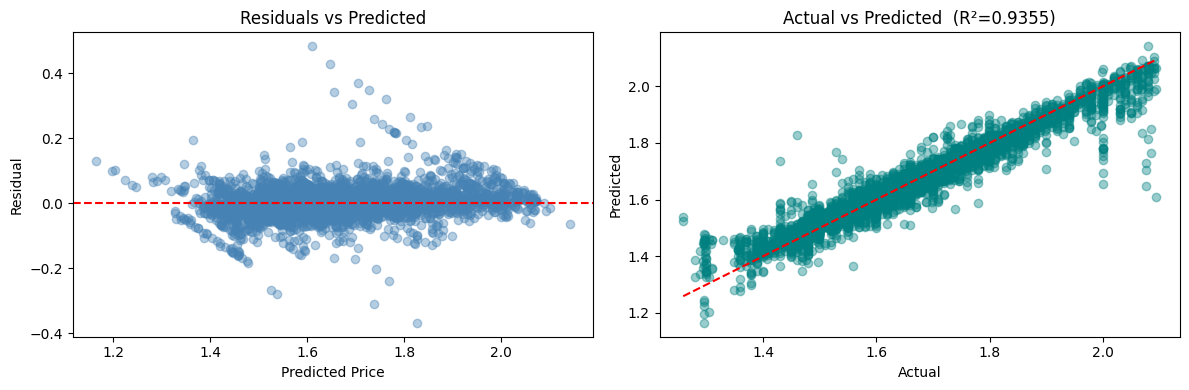

In [11]:
# --- 7. EVALUATION ---

best_model = search.best_estimator_

# Test set evaluation
preds = best_model.predict(X_test)
r2   = r2_score(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))
mae  = mean_absolute_error(y_test, preds)

# Cross-validation on full data (  3 pattern)
cv_scores = cross_val_score(best_model, X, y, cv=5, scoring='r2')

print("="*55)
print("        📈  FINAL MODEL EVALUATION")
print("="*55)
print(f"  Test R²  Score  : {r2:.4f}")
print(f"  Test RMSE       : {rmse:.4f}")
print(f"  Test MAE        : {mae:.4f}")
print(f"  CV R² (5-fold)  : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print("="*55)

# Residuals plot
residuals = y_test - preds
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(preds, residuals, alpha=0.4, color='steelblue')
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Predicted Price'); axes[0].set_ylabel('Residual')
axes[0].set_title('Residuals vs Predicted')

axes[1].scatter(y_test, preds, alpha=0.4, color='teal')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[1].set_xlabel('Actual'); axes[1].set_ylabel('Predicted')
axes[1].set_title(f'Actual vs Predicted  (R²={r2:.4f})')

plt.tight_layout()
plt.show()

# 💾 Step 8: MLflow Logging & Model Export (  3)

In [12]:
# --- 8. MLFLOW TRACKING ---

mlflow.set_experiment("Gas_Price_Improved_R2")

with mlflow.start_run(run_name="GBR_Tuned_FeatureEngineered"):

    # Log all best hyperparameters
    for param, value in search.best_params_.items():
        mlflow.log_param(param.replace('regressor__', ''), value)

    mlflow.log_param("n_features", len(numerical_features) + len(categorical_features))
    mlflow.log_param("outlier_method", "IQR_2.0")
    mlflow.log_param("scaler", "RobustScaler")
    mlflow.log_param("encoder", "TargetEncoder")

    mlflow.log_metric("R2_Score",  r2)
    mlflow.log_metric("RMSE",      rmse)
    mlflow.log_metric("MAE",       mae)
    mlflow.log_metric("CV_R2_mean", cv_scores.mean())
    mlflow.log_metric("CV_R2_std",  cv_scores.std())

    mlflow.sklearn.log_model(best_model, "gas_model_improved")

# Save model
output_dir = 'production_models'
os.makedirs(output_dir, exist_ok=True)
joblib.dump(best_model, os.path.join(output_dir, 'gas_price_model_improved.pkl'))

print(f"✅ Model R²  : {r2:.4f}")
print(f"✅ CV R² (5-fold mean): {cv_scores.mean():.4f}")
print(f"✅ Model saved to     : {output_dir}/gas_price_model_improved.pkl")

2026/05/02 10:10:20 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/05/02 10:10:20 INFO mlflow.store.db.utils: Updating database tables
2026-05-02 10:10:20 INFO  [alembic.runtime.migration] Context impl SQLiteImpl.
2026-05-02 10:10:20 INFO  [alembic.runtime.migration] Will assume non-transactional DDL.
2026-05-02 10:10:20 INFO  [alembic.runtime.migration] Context impl SQLiteImpl.
2026-05-02 10:10:20 INFO  [alembic.runtime.migration] Will assume non-transactional DDL.
2026/05/02 10:10:20 INFO mlflow.tracking.fluent: Experiment with name 'Gas_Price_Improved_R2' does not exist. Creating a new experiment.
2026/05/02 10:10:21 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/02 10:10:30 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/05/02 10:10:31 WARNING mlflow.models.model: Model logged without a signatu

✅ Model R²  : 0.9355
✅ CV R² (5-fold mean): -2.1203
✅ Model saved to     : production_models/gas_price_model_improved.pkl
